Accuracy: 65.51724137931035

Confusion Matrix:
 [[33  8]
 [12  5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.80      0.77        41
           1       0.38      0.29      0.33        17

    accuracy                           0.66        58
   macro avg       0.56      0.55      0.55        58
weighted avg       0.63      0.66      0.64        58



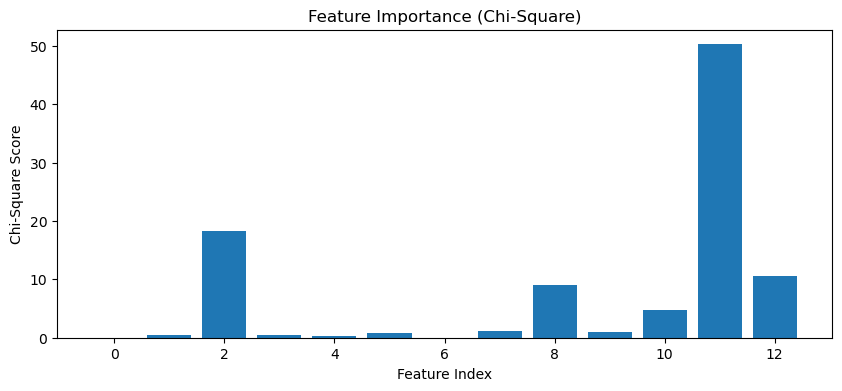

In [1]:

# 1️⃣ Imports
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

dataset = pd.read_csv('datasets-uci-breast-cancer.csv')

# Replace '?' with NaN
dataset.replace('?', np.nan, inplace=True)

# Encode target
label_encoder = LabelEncoder()
dataset['Class'] = label_encoder.fit_transform(dataset['Class'])

ordinal_feats = ['age', 'tumor-size', 'inv-nodes', 'deg-malig']
nominal_feats = ['menopause', 'node-caps', 'breast', 'breast-quad', 'irradiat']

# Remove extra quotes if any
for col in ordinal_feats + nominal_feats:
    dataset[col] = dataset[col].str.replace("'", "", regex=False)

# Helper function to auto-sort ordinal ranges

def sort_ordinal_categories(series):
    """
    Sorts ordinal categories like '20-29', '0-4', '1', '3-5'
    based on the numeric lower bound
    """
    return sorted(series.dropna().unique(), key=lambda x: int(x.split('-')[0]))

ordinal_categories = [sort_ordinal_categories(dataset[col]) for col in ordinal_feats]

X = dataset.drop('Class', axis=1)
y = dataset['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=122, stratify=y
)

# Nominal pipeline (dense output)
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False))
])

# Ordinal pipeline (with sorted categories)
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_categories))
])

# Column transformer
preprocessor = ColumnTransformer([
    ('nominal', nominal_pipeline, nominal_feats),
    ('ordinal', ordinal_pipeline, ordinal_feats)
])

model = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', SelectKBest(score_func=chi2, k='all')),
    ('classifier', GaussianNB())
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred) * 100)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

fs = model.named_steps['feature_selection']
scores = fs.scores_

plt.figure(figsize=(10,4))
plt.bar(range(len(scores)), scores)
plt.xlabel("Feature Index")
plt.ylabel("Chi-Square Score")
plt.title("Feature Importance (Chi-Square)")
plt.show()
